In [1]:
%cd ../../

/home/hoanghu/projects/ylva/fwo_models


In [2]:
from datetime import time
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns
import polars as pl
from sklearn.ensemble import IsolationForest

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Read data

In [4]:
path_root = Path("data/raw/occupancy_supersight")
paths = [path for path in path_root.glob("./**/*.xlsx")]

occu_raw = pl.concat([pl.read_excel(path) for path in paths])

occu_raw.head()

dateCreated,countIn,countOut,phoneName
str,i64,i64,str
"""2024-11-07T05:29:52.000Z""",1,0,"""S63"""
"""2024-11-07T05:56:16.000Z""",1,0,"""S63"""
"""2024-11-07T05:57:15.000Z""",0,1,"""S63"""
"""2024-11-07T05:58:34.000Z""",1,0,"""S63"""
"""2024-11-07T05:59:04.000Z""",1,0,"""S63"""


In [5]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';')
    df.columns = [str(x) for x in np.arange(df.shape[1])]
    raw.append(df)


pos_raw = pl.concat(raw)
pos_raw.head()

0,1,2,3,4,5,6
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


# Process

## POS

In [6]:
map_resname = pl.DataFrame([
    {'restaurant_full': '610 Physicum', 'restaurant': 'physicum'},
    {'restaurant_full': '600 Chemicum', 'restaurant': 'chemicum'},
    {'restaurant_full': '570 Viikuna', 'restaurant': 'viikuna'},
    {'restaurant_full': '620 Exactum', 'restaurant': 'exactum'},
])

map_resname.head()

restaurant_full,restaurant
str,str
"""610 Physicum""","""physicum"""
"""600 Chemicum""","""chemicum"""
"""570 Viikuna""","""viikuna"""
"""620 Exactum""","""exactum"""


In [7]:
pos_raw.columns = [
    'date',
    'time',
    'restaurant_full',
    'meal_type',
    'meal',
    'pcs',
    'co2',
]

pos = (
    pos_raw
    .with_columns(
        pl.concat_str(['date', 'time']).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
        # pl.col('date').str.to_date("%d.%m.%Y"),
        # pl.col('time').str.to_time("%H:%M"),
    )

    .join(map_resname, on='restaurant_full')

    .select('datetime', 'restaurant', 'pcs')
)

pos.head()

datetime,restaurant,pcs
datetime[μs],str,i64
2023-01-02 10:31:00,"""chemicum""",1
2023-01-02 10:32:00,"""chemicum""",1
2023-01-02 10:32:00,"""chemicum""",1
2023-01-02 10:35:00,"""chemicum""",1
2023-01-02 10:36:00,"""chemicum""",2


## Occupancy

In [8]:
path = "data/raw/occupancy_supersight/mapping_phoneName.csv"
map_phoneName2location = pl.read_csv(path)

map_phoneName2location

phoneName,location
str,str
"""S113""","""physicum_corridor"""
"""S82""","""exactum_maindoor"""
"""S86""","""physicum_corridor"""
"""S33""","""exactum_unicafe_stairs"""
"""S63""","""exactum_staffdoor"""
"""S59""","""chemicum_unicafe_entrance"""
"""S163""","""exactum_unicafe_stairs"""
"""S216""","""chemicum_unicafe_entrance"""
"""S217""","""physicum_cafeteria"""


In [9]:
occu = (
    occu_raw
    .with_columns(pl.col('dateCreated').str.to_datetime())
    .join(map_phoneName2location, on='phoneName', how='left')
    .drop('phoneName')
    .rename({'dateCreated': 'datetime'})
    
    .with_columns(
        pl.col('datetime').dt.convert_time_zone('Europe/Helsinki')
    )
)

occu.head()

datetime,countIn,countOut,location
"datetime[μs, Europe/Helsinki]",i64,i64,str
2024-11-07 07:29:52 EET,1,0,"""exactum_staffdoor"""
2024-11-07 07:56:16 EET,1,0,"""exactum_staffdoor"""
2024-11-07 07:57:15 EET,0,1,"""exactum_staffdoor"""
2024-11-07 07:58:34 EET,1,0,"""exactum_staffdoor"""
2024-11-07 07:59:04 EET,1,0,"""exactum_staffdoor"""


In [10]:
(
    occu
    .group_by('location')
    .agg(
        pl.col('datetime').min().alias('datetime_min'),
        pl.col('datetime').max().alias('datetime_max'),
    )
)

location,datetime_min,datetime_max
str,"datetime[μs, Europe/Helsinki]","datetime[μs, Europe/Helsinki]"
"""physicum_corridor""",2024-03-15 07:14:19 EET,2024-12-28 12:28:03 EET
"""exactum_unicafe_stairs""",2024-03-15 08:45:23 EET,2024-12-28 14:08:35 EET
"""physicum_cafeteria""",2024-05-27 16:51:28 EEST,2024-12-23 16:27:53 EET
"""exactum_staffdoor""",2024-03-15 06:26:15 EET,2024-12-28 13:33:06 EET
"""exactum_maindoor""",2024-03-15 07:07:20 EET,2024-12-28 13:45:27 EET
"""chemicum_unicafe_entrance""",2024-05-27 16:43:26 EEST,2024-12-27 15:55:53 EET


# EDA

### Prepare common dim tables

In [11]:
def gen_timeslot(
    restaurant: Literal["chemicum", "viikuna", "physicum", "exactum"],
    resolution: int
):
    time_start, time_end = None, None
    match (restaurant):
        case "chemicum":
            time_start = time(10, 30)
            time_end = time(15)
        case "viikuna":
            time_start = time(10, 30)
            time_end = time(14)
        case "physicum":
            time_start = time(10)
            time_end = time(16, 30)
        case "exactum":
            time_start = time(11)
            time_end = time(14)
        case _:
            raise NotImplementedError()

    timeslot = (
        pl.DataFrame({
            'time_start': pl.time_range(time_start, time_end, f"{resolution}m", eager=True),
        })
        .with_columns(
            pl.col('time_start').shift(-1).alias('time_end')
        )
        .drop_nulls()
        .with_row_index('slot')
    )

    return timeslot

gen_timeslot('chemicum', 1).head()

slot,time_start,time_end
u32,time,time
0,10:30:00,10:31:00
1,10:31:00,10:32:00
2,10:32:00,10:33:00
3,10:33:00,10:34:00
4,10:34:00,10:35:00


In [12]:
map_weekday2name = { 
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
}

### Visualize total for specific location for `occupancy` and `pos`

In [13]:
# location = 'chemicum_unicafe_entrance'
# restaurant = 'chemicum'
# resolution = 3



# # Determine start and end dates
# dates_pos = (
#     pos
#     .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
#     .filter(pl.col('restaurant') == pl.lit(restaurant))
#     .select(
#         pl.col('datetime').dt.date().min().alias('date_min'),
#         pl.col('datetime').dt.date().max().alias('date_max')
#     )
#     .to_dicts()
# )[0]

# dates_occu = (
#     occu
#     .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
#     .filter(pl.col('location') == pl.lit(location))
#     .select(
#         pl.col('datetime').dt.date().min().alias('date_min'),
#         pl.col('datetime').dt.date().max().alias('date_max')
#     )
#     .to_dicts()
# )[0]

# date_start = max(dates_occu['date_min'], dates_pos['date_min'])
# date_end = min(dates_occu['date_max'], dates_pos['date_max'])



# # Extract data
# timeslot = gen_timeslot(restaurant, resolution)
# pos_res = (
#     pos
#     .filter(
#         (pl.col('datetime').dt.weekday() < 6)           # Filter out Saturday and Sunday

#         & (pl.col('restaurant') == pl.lit(restaurant))  # Keep specified restaurant

#         & (pl.col('datetime').dt.date() >= date_start)
#         & (pl.col('datetime').dt.date() <= date_end)
#     )

#     .join(timeslot, how='cross')
#     .filter(
#         (pl.col('datetime').dt.time() >= pl.col('time_start'))
#         & (pl.col('datetime').dt.time() < pl.col('time_end'))
#     )
#     .drop('time_start', 'time_end')
#     .group_by('slot')
#     .agg(
#         pl.col('pcs').sum(),
#     )
# )

# occu_res = (
#     occu
#     .filter(
#         (pl.col('datetime').dt.weekday() < 6)           # Filter out Saturday and Sunday

#         & (pl.col('location') == pl.lit(location))      # Keep specified restaurant

#         & (pl.col('datetime').dt.date() >= date_start)
#         & (pl.col('datetime').dt.date() <= date_end)
#     )

#     .join(timeslot, how='cross')
#     .filter(
#         (pl.col('datetime').dt.time() >= pl.col('time_start'))
#         & (pl.col('datetime').dt.time() < pl.col('time_end'))
#     )
#     .drop('time_start', 'time_end')

#     .group_by('slot')
#     .agg(
#         pl.col('countIn').sum(),
#         pl.col('countOut').sum(),
#     )
# )

# df = (
#     occu_res
#     .join(pos_res, on='slot')

#     .join(timeslot, on='slot')

#     .with_columns(
#         pl.col('countIn').cum_sum().over(pl.lit(1), order_by='time_start').alias('in_cum'),
#         pl.col('countOut').cum_sum().over(pl.lit(1), order_by='time_start').alias('out_cum')
#     )
#     # .with_columns(
#     #     (pl.col('in_cum') - pl.col('out_cum')).alias('occupancy')
#     # )

#     # Unpivot
#     .unpivot(index=['slot', 'time_start'], on=['countIn', 'countOut', 'pcs'], value_name='count', variable_name='type')


#     .to_pandas()
# )




# # Plot
# df['time_start'] = pd.to_datetime(df['time_start'], format="%H:%M:%S")

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)

# sns.lineplot(df, y='count', x='time_start', ax=ax, hue='type')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlabel("Time")
# ax.set_title(f"Total in {restaurant} | resolution = {resolution} minutes", fontdict={'weight': 'bold', 'size': 14})
# ax.tick_params(axis='x', labelrotation = 45)

### Visualize total per restaurant on specific date

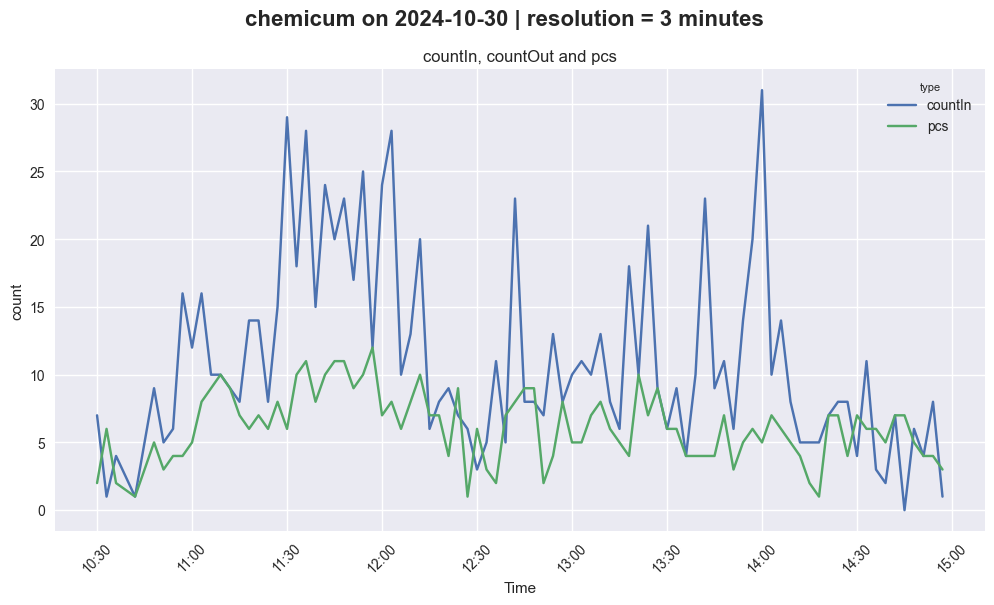

In [14]:
location = 'chemicum_unicafe_entrance'
restaurant = 'chemicum'
date_plot = '2024-10-30'
resolution = 3



# Prepare data
timeslot = gen_timeslot(restaurant, resolution)


occu_res = (
    occu
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
    
    .filter(
        (pl.col('location') == pl.lit(location))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )
    .join(timeslot, how='cross')
    .filter(
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')

    .group_by('slot')
    .agg(
        pl.col('countIn').sum(),
        pl.col('countOut').sum(),
    )
)


pos_res = (
    pos
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday

    .filter(
        (pl.col('restaurant') == pl.lit(restaurant))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )

    .join(timeslot, how='cross')
    .filter(
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')
    .group_by('slot')
    .agg(
        pl.col('pcs').count(),
    )
)


df = (
    occu_res
    .join(pos_res, on='slot')

    .join(timeslot, on='slot')

    .with_columns(
        pl.col('countIn').cum_sum().over(pl.lit(1), order_by='time_start').alias('in_cum'),
        pl.col('countOut').cum_sum().over(pl.lit(1), order_by='time_start').alias('out_cum')
    )
    .with_columns(
        (pl.col('in_cum') - pl.col('out_cum')).alias('occupancy'),
        (pl.col('countIn') - pl.col('pcs')).alias('count_diff'),
    )

    # Unpivot
    .unpivot(index=['slot', 'time_start'], on=[
        'countIn', 
        # 'countOut', 
        'pcs', 
        # 'occupancy'
        # 'count_diff'
    ], value_name='count', variable_name='type')


    .to_pandas()
)



# Plot
df['time_start'] = pd.to_datetime(df['time_start'], format="%H:%M:%S")


fig = plt.figure(figsize=(12, 6))
fig.suptitle(f"{restaurant} on {date_plot} | resolution = {resolution} minutes", fontweight='bold', fontsize=16)

ax = fig.add_subplot(111)
sns.lineplot(df[df['type'] != 'count_diff'], y='count', x='time_start', ax=ax, hue='type')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Time")
ax.set_title('countIn, countOut and pcs')
ax.tick_params(axis='x', labelrotation = 45)

# ax = fig.add_subplot(122)
# sns.lineplot(df[df['type'] == 'count_diff'], y='count', x='time_start', ax=ax, hue='type')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.set_xlabel("Time")
# ax.set_title('Solution 1: Diff between countIn and pcs')
# ax.axhline(y = 5, color = 'r', linestyle = '--')
# ax.tick_params(axis='x', labelrotation = 45)

### Visualize total per restaurant and weekday

In [15]:
# restaurant = 'physicum'

# # Determine start and end dates
# dates_pos = (
#     pos
#     .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
#     .filter(pl.col('restaurant') == pl.lit(restaurant))
#     .select(
#         pl.col('datetime').dt.date().min().alias('date_min'),
#         pl.col('datetime').dt.date().max().alias('date_max')
#     )
#     .to_dicts()
# )[0]

# dates_occu = (
#     occu
#     .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
#     .filter(pl.col('restaurant') == pl.lit(restaurant))
#     .select(
#         pl.col('datetime').dt.date().min().alias('date_min'),
#         pl.col('datetime').dt.date().max().alias('date_max')
#     )
#     .to_dicts()
# )[0]

# date_start = max(dates_occu['date_min'], dates_pos['date_min'])
# date_end = min(dates_occu['date_max'], dates_pos['date_max'])


# occu_res = (
#     occu
#     .filter(
#         (pl.col('datetime').dt.weekday() < 6)           # Filter out Saturday and Sunday

#         & (pl.col('restaurant') == pl.lit(restaurant))  # Keep specified restaurant

#         & (pl.col('datetime').dt.date() >= date_start)
#         & (pl.col('datetime').dt.date() <= date_end)
#     )
#     .join(timeslot, how='cross')
#     .filter(
#         (pl.col('datetime').dt.time() >= pl.col('time_start'))
#         & (pl.col('datetime').dt.time() < pl.col('time_end'))
#     )
#     .drop('time_start', 'time_end')

#     .with_columns(
#         pl.col('datetime').dt.weekday().cast(pl.Int64).alias('weekday')
#     )

#     .group_by('weekday', 'slot')
#     .agg(
#         pl.col('countIn').sum(),
#         pl.col('countOut').sum(),
#     )
# )


# pos_res = (
#     pos
#     .filter(
#         (pl.col('datetime').dt.weekday() < 6)           # Filter out Saturday and Sunday

#         & (pl.col('restaurant') == pl.lit(restaurant))  # Keep specified restaurant

#         & (pl.col('datetime').dt.date() >= date_start)
#         & (pl.col('datetime').dt.date() <= date_end)
#     )

#     .join(timeslot, how='cross')
#     .filter(
#         (pl.col('datetime').dt.time() >= pl.col('time_start'))
#         & (pl.col('datetime').dt.time() < pl.col('time_end'))
#     )
#     .drop('time_start', 'time_end')

#     .with_columns(
#         pl.col('datetime').dt.weekday().cast(pl.Int64).alias('weekday')
#     )

#     .group_by('weekday', 'slot')
#     .agg(
#         pl.col('pcs').sum(),
#     )
# )


# df = (
#     occu_res
#     .join(pos_res, on=['weekday', 'slot'])

#     .join(timeslot, on='slot')

#     # Unpivot
#     .unpivot(index=['weekday', 'slot', 'time_start'], on=['countIn', 'countOut', 'pcs'], value_name='count', variable_name='type')

#     # .join(map_weekday2name, on='weekday')
#     # .drop('weekday')
#     # .rename({'name': 'weekday'})


#     .to_pandas()
# )





# # Plot
# df['time_start'] = pd.to_datetime(df['time_start'], format="%H:%M:%S")
# weekdays = sorted(df['weekday'].unique())

# fig = plt.figure(figsize=(12, 10))
# fig.subplots_adjust(wspace=0.2, hspace=0.6, top=0.9)
# fig.suptitle(f"Total in {restaurant} per weekday", fontweight='bold', fontsize=16)

# for idx, weekday in enumerate(weekdays):
#     ax = fig.add_subplot(3, 2, idx + 1)

#     sns.lineplot(df[df['weekday'] == weekday], y='count', x='time_start', ax=ax, hue='type')
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#     ax.set_xlabel("Time")
#     ax.set_title(map_weekday2name[weekday])
#     ax.tick_params(axis='x', labelrotation = 45)

# Queue detection

In [16]:
location = 'chemicum_unicafe_entrance'
restaurant = 'chemicum'
date_plot = '2024-10-30'
resolution = 3

### Solution 1: Measuring the absolute difference

<Axes: title={'center': 'Diff between countIn and pcs'}, xlabel='Time', ylabel='count'>

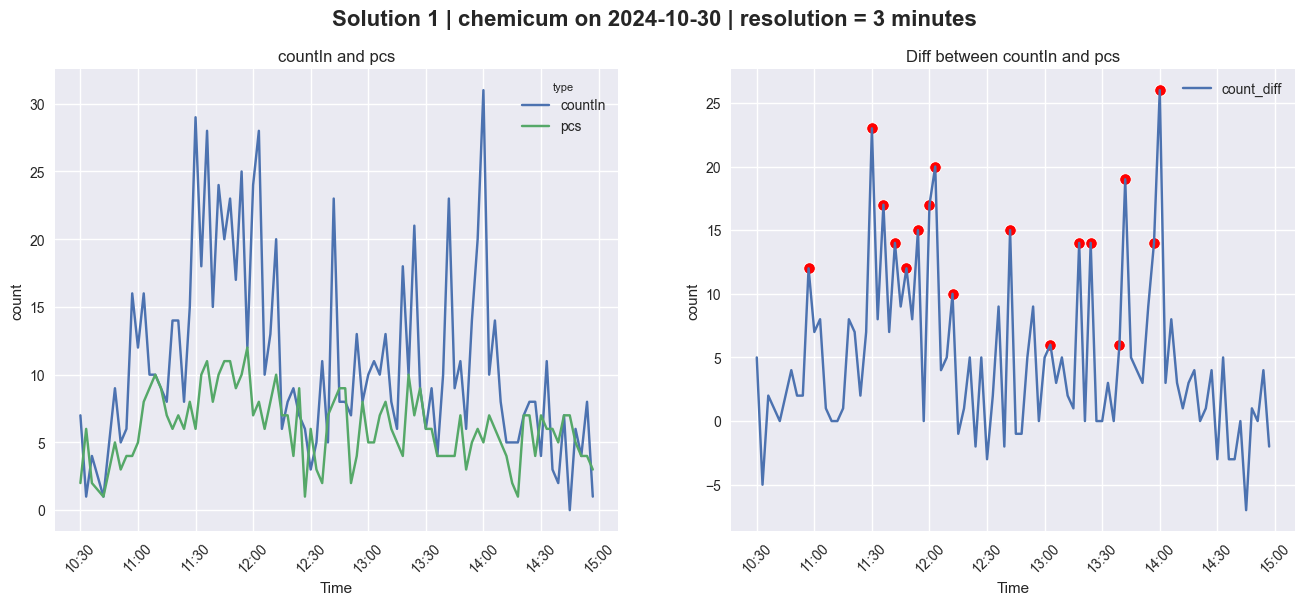

In [18]:
location = 'chemicum_unicafe_entrance'
restaurant = 'chemicum'
date_plot = '2024-10-30'
resolution = 3



# Prepare data
timeslot = gen_timeslot(restaurant, resolution)


occu_res = (
    occu
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
    
    .filter(
        (pl.col('location') == pl.lit(location))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )
    .join_where(
        timeslot,
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')

    .group_by('slot')
    .agg(
        pl.col('countIn').sum(),
        pl.col('countOut').sum(),
    )
)


pos_res = (
    pos
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday

    .filter(
        (pl.col('restaurant') == pl.lit(restaurant))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )

    .join_where(
        timeslot,
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')
    .group_by('slot')
    .agg(
        pl.col('pcs').count(),
    )
)


df = (
    occu_res
    .join(pos_res, on='slot')

    .join(timeslot, on='slot')

    .with_columns(
        pl.col('countIn').cum_sum().over(pl.lit(1), order_by='time_start').alias('in_cum'),
        pl.col('countOut').cum_sum().over(pl.lit(1), order_by='time_start').alias('out_cum')
    )
    .with_columns(
        (pl.col('in_cum') - pl.col('out_cum')).alias('occupancy'),
        (pl.col('countIn') - pl.col('pcs')).alias('count_diff'),
    )

    # Unpivot
    .unpivot(index=['slot', 'time_start'], on=[
        'countIn', 
        # 'countOut', 
        'pcs', 
        # 'occupancy'
        'count_diff'
    ], value_name='count', variable_name='type')


    .to_pandas()
)


# Determine the anomaly
occu_queue = df[df['type'] == 'count_diff'][['time_start', 'count']].copy()
occu_queue['anomaly'] = IsolationForest().fit_predict(occu_queue['count'].to_numpy()[:, None])
occu_queue = occu_queue[(occu_queue['anomaly'] == -1) & (occu_queue['count'] > 0)]
occu_queue['time_start'] = pd.to_datetime(occu_queue['time_start'], format="%H:%M:%S")


# Plot
df['time_start'] = pd.to_datetime(df['time_start'], format="%H:%M:%S")


fig = plt.figure(figsize=(16, 6))
fig.suptitle(f"Solution 1 | {restaurant} on {date_plot} | resolution = {resolution} minutes", fontweight='bold', fontsize=16)

ax = fig.add_subplot(121)
sns.lineplot(df[df['type'] != 'count_diff'], y='count', x='time_start', ax=ax, hue='type')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Time")
ax.set_title('countIn and pcs')
ax.tick_params(axis='x', labelrotation = 45)

ax = fig.add_subplot(122)
sns.lineplot(df[df['type'] == 'count_diff'], y='count', x='time_start', ax=ax, hue='type')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Time")
ax.set_title('Diff between countIn and pcs')
ax.tick_params(axis='x', labelrotation = 45)


sns.scatterplot(occu_queue, x='time_start', y='count', markers='o', s=70, c='r')

### Solution 2: Applying anomaly detection with standard deviation

In [141]:
# Generate the timeslot for all restaurants
dfs = []
for res in ["chemicum", "viikuna", "physicum", "exactum"]:
    df = gen_timeslot(res, resolution)
    df = df.with_columns(pl.lit(res).alias('restaurant'))
    dfs.append(df)

timeslots = pl.concat(dfs)



# Calcualte the mean and std of pcs per restaurant and slot
pos_info = (
    pos
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday

    .join_where(
        timeslots,
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
        & (pl.col('restaurant') == pl.col('restaurant_right'))
    )
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )
    .group_by('restaurant', 'slot', 'date')
    .agg(
        pl.col('pcs').sum()
    )
    .group_by('restaurant', 'slot')
    .agg(
        pl.col('pcs').mean().alias('pcs_mean'),
        pl.col('pcs').std().alias('pcs_std'),
    )
)

pos_info.head()

restaurant,slot,pcs_mean,pcs_std
str,u32,f64,f64
"""chemicum""",35,15.665948,5.940166
"""viikuna""",57,2.601974,1.58462
"""physicum""",51,1.845494,1.141758
"""chemicum""",19,10.627451,5.289293
"""exactum""",25,8.39313,4.336651


In [142]:
THETA = 3

# Prepare data
timeslot = gen_timeslot(restaurant, resolution)


occu_queue = (
    occu
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
    
    .filter(
        (pl.col('location') == pl.lit(location))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )
    .join_where(
        timeslot,
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')

    .group_by('slot')
    .agg(
        pl.col('countIn').sum(),
    )


    # Get mean and std pos
    .join(
        pos_info.filter(pl.col('restaurant') == pl.lit(restaurant)),
        on='slot',
        how='left'
    )
    .filter(pl.col('countIn') >= pl.col('pcs_mean') * THETA)


    # # Supplement timing info for slots
    .join(timeslot, on='slot')


    # Remove redundant columns
    .drop('restaurant', 'pcs_mean', 'pcs_std', 'slot', 'time_end')


    .to_pandas()
)

occu_queue['time_start'] = pd.to_datetime(occu_queue['time_start'], format="%H:%M:%S")

occu_queue

,countIn,time_start
0,16,1900-01-01 10:57:00
1,23,1900-01-01 13:42:00
2,31,1900-01-01 14:00:00


<Axes: title={'center': 'countIn and pcs'}, xlabel='Time', ylabel='count'>

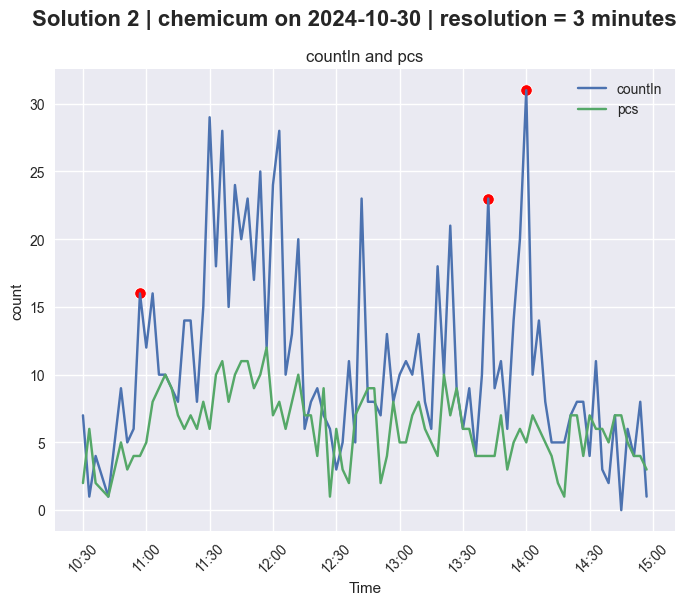

In [143]:
# Prepare data
timeslot = gen_timeslot(restaurant, resolution)


occu_res = (
    occu
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday
    
    .filter(
        (pl.col('location') == pl.lit(location))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )
    .join_where(
        timeslot,
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')

    .group_by('slot')
    .agg(
        pl.col('countIn').sum(),
        pl.col('countOut').sum(),
    )
)


pos_res = (
    pos
    .filter(pl.col('datetime').dt.weekday() < 6)        # Filter out Saturday and Sunday

    .filter(
        (pl.col('restaurant') == pl.lit(restaurant))
        & (pl.col('datetime').dt.date() == pl.lit(date_plot).str.to_date())
    )

    .join_where(
        timeslot,
        (pl.col('datetime').dt.time() >= pl.col('time_start'))
        & (pl.col('datetime').dt.time() < pl.col('time_end'))
    )
    .drop('time_start', 'time_end')
    .group_by('slot')
    .agg(
        pl.col('pcs').count(),
    )
)


df = (
    occu_res
    .join(pos_res, on='slot')

    .join(timeslot, on='slot')

    .with_columns(
        pl.col('countIn').cum_sum().over(pl.lit(1), order_by='time_start').alias('in_cum'),
        pl.col('countOut').cum_sum().over(pl.lit(1), order_by='time_start').alias('out_cum')
    )
    .with_columns(
        # (pl.col('in_cum') - pl.col('out_cum')).alias('occupancy'),
        (pl.col('countIn') - pl.col('pcs')).alias('count_diff'),
    )

    # Unpivot
    .unpivot(index=['slot', 'time_start'], on=[
        'countIn', 
        # 'countOut', 
        'pcs', 
        # 'occupancy'
        # 'count_diff'
    ], value_name='count', variable_name='type')


    .to_pandas()
)



# Plot
df['time_start'] = pd.to_datetime(df['time_start'], format="%H:%M:%S")


fig = plt.figure(figsize=(8, 6))
fig.suptitle(f"Solution 2 | {restaurant} on {date_plot} | resolution = {resolution} minutes", fontweight='bold', fontsize=16)

ax = fig.add_subplot(111)
sns.lineplot(df[df['type'] != 'count_diff'], y='count', x='time_start', ax=ax, hue='type')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Time")
ax.set_title('countIn and pcs')
ax.tick_params(axis='x', labelrotation = 45)


sns.scatterplot(occu_queue, x='time_start', y='countIn', markers='o', s=70, c='r')